In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il
import pandas as pd
from matplotlib.lines import Line2D

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
snapnum = 72

In [4]:
boxsize=205

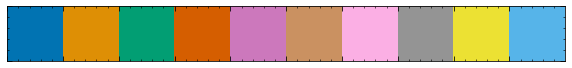

In [5]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
sns.palplot(palette_tab10)

In [6]:
color_list = palette_tab10[1:2] +  palette_tab10[2:3] +  palette_tab10[4:5] 

In [7]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [8]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [9]:
h = 0.6774

In [10]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [11]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [12]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10
<class 'dict'>


In [13]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [14]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [15]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [16]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [17]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [18]:
sum_sfrs = np.zeros(len(group_sfrs))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [25]:
fontsize=18

z = 0.4
z_eag = 0.37
z_tng = 0.4 
z_sobral = 0.4
z_gruppioni = 0.375
z_arnouts = 0.3

data_dir = "data/z=0.4"

dust = -1/2.5


df_sobral = pd.read_csv(f"{data_dir}/Sobral-0.4.csv")
df_gruppioni = pd.read_csv(f"{data_dir}/Gruppioni-0.375.csv")
df_schechter = pd.read_csv(f"{data_dir}/Schechter_parameters_Cucciati-0.5.csv")
df_arnouts = pd.read_csv(f"{data_dir}/Arnouts-0.3.csv")

halo_types = ["all", "cent", "sat"]

df_eagles = []
df_tngs = []
ig10_eagles = []
ig10_tngs = []


for i, halo in enumerate(halo_types):
    df_eagle = pd.read_csv(f"{data_dir}/EAGLE/eagle_sfr_func_{halo}.csv")
    #df_tng = pd.read_csv(f"TNG/tng_sfr_func_{halo}.csv")
    df_eagles.append(df_eagle)
    #df_tngs.append(df_tng)


    ig10_eagle = np.where(df_eagle["number"] > 10)[0][-1]
    #ig10_tng = np.where(df_tng["number"] > 10)[0][-1]
    ig10_eagles.append(ig10_eagle)
    #ig10_tngs.append(ig10_tng)



def L2sfr(X): # For Halpha
    V = X + np.log10(4.4 * 10**-42)
    return V

def sfr2L(X): # For Halpha
    V = X - np.log10(4.4 * 10**-42)
    return V

def lin2log_err(val, err_up,err_down=-1):
    if err_down == -1:
        err_down = err_up
    log_err_up = np.log10(val + err_up) - np.log10(val)
    log_err_down = np.log10(val) - np.log10(val - err_down)
    return log_err_up, log_err_down

gruppioni_err = lin2log_err(df_gruppioni["phi"], df_gruppioni["phi_err"])[0]
gruppioni_phi = np.log10(df_gruppioni["phi"] * 10**-2)

schechter_dict = {}

L_arr = np.arange(40, 43.3, 0.1)

def schechter_phi(log_phi_star, L_arr, log_L_star, alpha):
    phi = np.log(10)* 10**(log_phi_star) * 10**((L_arr-log_L_star)*(alpha+1)) * np.exp(-10**(L_arr-log_L_star))
    return phi

M_arr = np.arange(-21, -15, 0.1)
alpha = df_arnouts["alpha"][0]
log_phi_star = np.log10(df_arnouts["phi_star"][0] * 10**-3)
M_star = df_arnouts["M_star"][0]
phi_arnouts = (np.log(10)/2.5) * 10**log_phi_star * 10**(0.4 * (alpha+1) * (M_star - M_arr)) * np.exp(-10**(0.4*(M_star-M_arr))) # Schechter for magnitudes
phi_arnouts = np.log10(phi_arnouts)
print(phi_arnouts)


def M2L(M):
    r0 = 10 # parsec
    r0 = r0 * 3.0856 * 1e18 # cm
    logf = -(M + 48.60)/2.5 # Oke & Gunn 1983
    f_nu = 10**logf # erg s-1 cm-2 Hz-1

    L = 4 * np.pi * r0**2 * f_nu # erg s-1 Hz-1
    logL = np.log10(L)
    return logL


# Dust correction for UV
beta = df_arnouts["beta"][0]
d_beta = df_arnouts["dbeta"][0]
beta_av = d_beta * (M_arr + 19.5) + beta

A1600 = 4.43 + (1.99 * beta_av)
tau_UV = A1600 / 1.086

L_UVobs = M2L(M_arr)
L_UVcorr = 10**L_UVobs * np.exp(tau_UV)
def L2sfr_UV(logL): # erg s-1 Hz-1# Chabrier
    logsfr = np.log10(0.77 * 10**-28 * 10**logL)
    return logsfr
sfr_arnouts = L2sfr_UV(np.log10(L_UVcorr))
print(sfr_arnouts)


[-7.29644466 -6.8620554  -6.46521896 -6.10263111 -5.77127835 -5.46841232
 -5.1915265  -4.93833491 -4.70675272 -4.49487853 -4.30097826 -4.1234704
 -3.96091258 -3.81198937 -3.67550108 -3.55035355 -3.43554894 -3.33017716
 -3.23340825 -3.14448523 -3.06271776 -2.98747622 -2.9181864  -2.85432462
 -2.79541326 -2.74101675 -2.69073782 -2.64421418 -2.6011154  -2.56114012
 -2.52401352 -2.48948493 -2.45732577 -2.42732756 -2.39930014 -2.37307011
 -2.34847932 -2.32538354 -2.30365122 -2.28316239 -2.26380764 -2.24548718
 -2.22811    -2.21159311 -2.19586081 -2.18084406 -2.16647991 -2.15271092
 -2.13948475 -2.12675361 -2.11447396 -2.10260607 -2.0911137  -2.07996382
 -2.0691263  -2.05857364 -2.04828078 -2.03822486 -2.02838504 -2.0187423 ]
[ 1.69721207  1.64686658  1.5965211   1.54617561  1.49583012  1.44548464
  1.39513915  1.34479367  1.29444818  1.24410269  1.19375721  1.14341172
  1.09306623  1.04272075  0.99237526  0.94202977  0.89168429  0.8413388
  0.79099331  0.74064783  0.69030234  0.63995686  0.

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:55: RuntimeWarning: divide by zero encountered in log10


In [62]:
h = 0.6774
volume = (boxsize/h)**3

In [63]:
def gen_LF(sfr, bin_edges, data2bin=None):
    if data2bin is None:
        data2bin = sfr
    total = np.sum(10**sfr)
    dbin = bin_edges[1] - bin_edges[0]
    bin_cents = (bin_edges[:-1] + bin_edges[1:]) / 2
    sums_list = np.zeros_like(bin_cents)
    for ibin, bin_left in enumerate(bin_edges[:-1]):
        mask = (data2bin > bin_left) & (data2bin < bin_edges[ibin+1])
        sums_list[ibin] = np.sum(mask)
    ig10 = np.where(sums_list > 10)[0][-1]
    return bin_cents, np.array(sums_list)/(volume*dbin), total, ig10

In [76]:
bin_edges_sfr = np.arange(-3.5, 4, 0.1)
bin_cents, cent_lf, total_cent, ig10_cent = gen_LF(cent_sfrs, bin_edges_sfr)
bin_cents, sat_lf, total_sat, ig10_sat = gen_LF(np.log10(sat_sfrs), bin_edges_sfr)
bin_cents, gal_lf, total_gal, ig10_gal = gen_LF(np.log10(subhalos["SubhaloSFR"]), bin_edges_sfr)
bin_cents, group_lf, total_group, ig10_group = gen_LF(group_sfrs, bin_edges_sfr)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log10
  """
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: divide by zero encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:35: RuntimeWarning: divide by zero encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:36: RuntimeWarning: divide by zero encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:40: RuntimeWarning: divide by zero encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: divide by zero encountered in log10


>>> output ../figures/sfr_func_w_dust_z=0.4.pdf


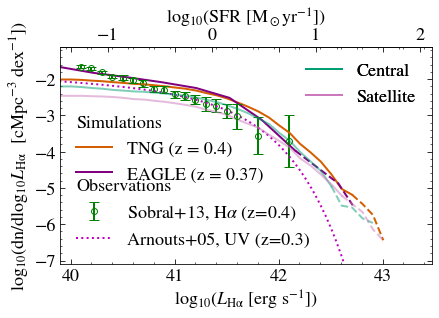

In [81]:

# other
# with dust
fig, ax = plt.subplots()
tng = ax.plot(sfr2L(bin_cents[:ig10_gal+1])+dust, np.log10(gal_lf[:ig10_gal+1]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[3])
tng = ax.plot(sfr2L(bin_cents[ig10_gal:])+dust, np.log10(gal_lf[ig10_gal:]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[3], linestyle="dashed")

eagle = ax.plot(sfr2L(df_eagles[0]["sfr"][:ig10_eagles[0]+1])+dust, np.log10(df_eagles[0]["phi"][:ig10_eagles[0]+1]), label= f"EAGLE (z = {z_eag})" , linewidth =2, c="purple")
eagle = ax.plot(sfr2L(df_eagles[0]["sfr"][ig10_eagles[0]:])+dust, np.log10(df_eagles[0]["phi"][ig10_eagles[0]:]), label= f"EAGLE (z = {z_eag})" , linewidth =2, linestyle="dashed", c="purple")
sobral_int = ax.errorbar(df_sobral["luminosity"]+dust, df_sobral["corr"], c="green", yerr=df_sobral["corr_err"], fmt="o", mfc="none", capsize=5)


ax.set_xlabel(r"log$_{10}$($L_{\rm H\alpha}$ [erg s$^{-1}$])", fontsize=fontsize)
ax.set_ylabel(r"log$_{10}$(dn/dlog$_{10}L_{\rm H\alpha}$  [cMpc$^{−3}$ dex$^{-1}$])", fontsize=fontsize)

handles1, labels1 = ax.get_legend_handles_labels()
sobral = ax.errorbar([],[], yerr=1, color="green", fmt="o", mfc="none", capsize=5)
leg_sim1 = ax.legend(handles1[::2], labels1[::2], columnspacing=1, 
                 bbox_to_anchor=(0,0.3), loc="lower left", frameon=False, title="Simulations")
leg_sim1._legend_box.align = "left"

ax.add_artist(leg_sim1)

#gruppioni = ax.errorbar(sfr2L(np.log10(df_gruppioni["sfr"])), gruppioni_phi, c="red", yerr=gruppioni_err, fmt="o", mfc="none", capsize=5)
arnouts, = ax.plot(sfr2L(sfr_arnouts)+dust, phi_arnouts, linestyle="dotted", c="m")

leg_sob = ax.legend([sobral_int, arnouts], [fr"Sobral+13, H$\alpha$ (z={z_sobral})", fr"Arnouts+05, UV (z={z_arnouts})"], borderaxespad=0.5, loc="lower left", frameon=False, title="Observations")

leg_sob._legend_box.align = "left"
ax.add_artist(leg_sob)
ax.set_xlim(39.9,)
ax.set_ylim(-7.1,)

#Cents
tng = ax.plot(sfr2L(bin_cents[:ig10_cent+1])+dust, np.log10(cent_lf[:ig10_cent+1]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[2], alpha=0.5)
tng = ax.plot(sfr2L(bin_cents[ig10_cent:])+dust, np.log10(cent_lf[ig10_cent:]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[2], alpha=0.5, linestyle="dashed")


#Sats
tng = ax.plot(sfr2L(bin_cents[:ig10_sat+1])+dust, np.log10(sat_lf[:ig10_sat+1]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[4], alpha=0.5)
tng = ax.plot(sfr2L(bin_cents[ig10_sat:])+dust, np.log10(sat_lf[ig10_sat:]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[4], alpha=0.5, linestyle="dashed")



cent = Line2D([],[],color=palette_tab10[2], linestyle="solid", label="Central")
sat = Line2D([],[],color=palette_tab10[4], linestyle="solid", label="Satellite")

leg = plt.legend(handles=[cent, sat])
ax.add_artist(leg)


ax2 = ax.secondary_xaxis('top', functions=(L2sfr, sfr2L))
ax2.set_xlabel(r"log$_{10}$(SFR [M$_\odot$yr$^{-1}$])", fontsize=fontsize)

#idir = "figures"
odir = "../figures"

fout = f"{odir}/sfr_func_w_dust_z=0.4.pdf"
plt.savefig(f"{odir}/{fout}", format="pdf", bbox_inches="tight")
print(">>> output "+fout)
plt.show()
plt.close(fig)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log10
  """
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: divide by zero encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:35: RuntimeWarning: divide by zero encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:36: RuntimeWarning: divide by zero encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:43: RuntimeWarning: divide by zero encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:44: RuntimeWarning: divide by zero encountered in log10


>>> output ../figures/sfr_func_w_dust_z=0.4.pdf


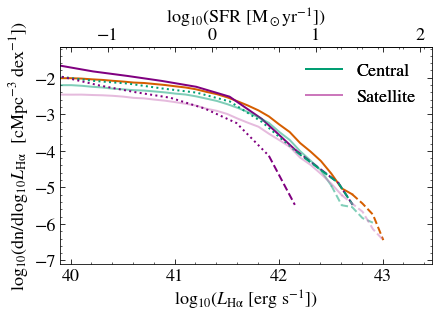

In [87]:

# other
# with dust
fig, ax = plt.subplots()
tng = ax.plot(sfr2L(bin_cents[:ig10_gal+1])+dust, np.log10(gal_lf[:ig10_gal+1]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[3])
tng = ax.plot(sfr2L(bin_cents[ig10_gal:])+dust, np.log10(gal_lf[ig10_gal:]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[3], linestyle="dashed")

eagle = ax.plot(sfr2L(df_eagles[0]["sfr"][:ig10_eagles[0]+1])+dust, np.log10(df_eagles[0]["phi"][:ig10_eagles[0]+1]), label= f"EAGLE (z = {z_eag})" , linewidth =2, c="purple")
eagle = ax.plot(sfr2L(df_eagles[0]["sfr"][ig10_eagles[0]:])+dust, np.log10(df_eagles[0]["phi"][ig10_eagles[0]:]), label= f"EAGLE (z = {z_eag})" , linewidth =2, linestyle="dashed", c="purple")
#sobral_int = ax.errorbar(df_sobral["luminosity"]+dust, df_sobral["corr"], c="green", yerr=df_sobral["corr_err"], fmt="o", mfc="none", capsize=5)


ax.set_xlabel(r"log$_{10}$($L_{\rm H\alpha}$ [erg s$^{-1}$])", fontsize=fontsize)
ax.set_ylabel(r"log$_{10}$(dn/dlog$_{10}L_{\rm H\alpha}$  [cMpc$^{−3}$ dex$^{-1}$])", fontsize=fontsize)

# handles1, labels1 = ax.get_legend_handles_labels()
# sobral = ax.errorbar([],[], yerr=1, color="green", fmt="o", mfc="none", capsize=5)
# leg_sim1 = ax.legend(handles1[::2], labels1[::2], columnspacing=1, 
#                  bbox_to_anchor=(0,0.3), loc="lower left", frameon=False, title="Simulations")
# leg_sim1._legend_box.align = "left"

# ax.add_artist(leg_sim1)

# #gruppioni = ax.errorbar(sfr2L(np.log10(df_gruppioni["sfr"])), gruppioni_phi, c="red", yerr=gruppioni_err, fmt="o", mfc="none", capsize=5)
# arnouts, = ax.plot(sfr2L(sfr_arnouts)+dust, phi_arnouts, linestyle="dotted", c="m")

# leg_sob = ax.legend([sobral_int, arnouts], [fr"Sobral+13, H$\alpha$ (z={z_sobral})", fr"Arnouts+05, UV (z={z_arnouts})"], borderaxespad=0.5, loc="lower left", frameon=False, title="Observations")

# leg_sob._legend_box.align = "left"
# ax.add_artist(leg_sob)
ax.set_xlim(39.9,)
ax.set_ylim(-7.1,)

#Cents
tng = ax.plot(sfr2L(bin_cents[:ig10_cent+1])+dust, np.log10(cent_lf[:ig10_cent+1]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[2], alpha=0.5)
tng = ax.plot(sfr2L(bin_cents[ig10_cent:])+dust, np.log10(cent_lf[ig10_cent:]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[2], alpha=0.5, linestyle="dashed")

eagle = ax.plot(sfr2L(df_eagles[1]["sfr"][:ig10_eagles[1]+1])+dust, np.log10(df_eagles[1]["phi"][:ig10_eagles[1]+1]), label= f"EAGLE (z = {z_eag})" , linewidth =2, linestyle="dotted", c=palette_tab10[2])
eagle = ax.plot(sfr2L(df_eagles[1]["sfr"][ig10_eagles[1]:])+dust, np.log10(df_eagles[1]["phi"][ig10_eagles[1]:]), label= f"EAGLE (z = {z_eag})" , linewidth =2, linestyle="dashed", c=palette_tab10[2])


#Sats
tng = ax.plot(sfr2L(bin_cents[:ig10_sat+1])+dust, np.log10(sat_lf[:ig10_sat+1]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[4], alpha=0.5)
tng = ax.plot(sfr2L(bin_cents[ig10_sat:])+dust, np.log10(sat_lf[ig10_sat:]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[4], alpha=0.5, linestyle="dashed")

eagle = ax.plot(sfr2L(df_eagles[2]["sfr"][:ig10_eagles[2]+1])+dust, np.log10(df_eagles[2]["phi"][:ig10_eagles[2]+1]), label= f"EAGLE (z = {z_eag})" , linewidth =2, linestyle="dotted", c="purple")
eagle = ax.plot(sfr2L(df_eagles[2]["sfr"][ig10_eagles[2]:])+dust, np.log10(df_eagles[2]["phi"][ig10_eagles[2]:]), label= f"EAGLE (z = {z_eag})" , linewidth =2, linestyle="dashed", c="purple")



cent = Line2D([],[],color=palette_tab10[2], linestyle="solid", label="Central")
sat = Line2D([],[],color=palette_tab10[4], linestyle="solid", label="Satellite")

leg = plt.legend(handles=[cent, sat])
ax.add_artist(leg)


ax2 = ax.secondary_xaxis('top', functions=(L2sfr, sfr2L))
ax2.set_xlabel(r"log$_{10}$(SFR [M$_\odot$yr$^{-1}$])", fontsize=fontsize)

#idir = "figures"
odir = "../figures"

fout = f"{odir}/sfr_func_w_dust_z={z_tng}.pdf"
#plt.savefig(f"{odir}/{fout}", format="pdf", bbox_inches="tight")
print(">>> output "+fout)
plt.show()
plt.close(fig)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log10
  """
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: divide by zero encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:35: RuntimeWarning: divide by zero encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:36: RuntimeWarning: divide by zero encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:43: RuntimeWarning: divide by zero encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:44: RuntimeWarning: divide by zero encountered in log10


>>> output ../figures/sfr_func_w_dust_z=0.4_eagle_vs_tng.pdf


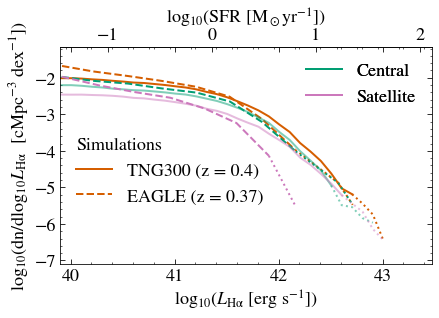

In [96]:

# other
# with dust
fig, ax = plt.subplots()
tng = ax.plot(sfr2L(bin_cents[:ig10_gal+1])+dust, np.log10(gal_lf[:ig10_gal+1]), label= f"TNG300 (z = {z_tng})" , linewidth =2, c=palette_tab10[3])
tng = ax.plot(sfr2L(bin_cents[ig10_gal:])+dust, np.log10(gal_lf[ig10_gal:]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[3], linestyle="dotted")

eagle = ax.plot(sfr2L(df_eagles[0]["sfr"][:ig10_eagles[0]+1])+dust, np.log10(df_eagles[0]["phi"][:ig10_eagles[0]+1]), label= f"EAGLE (z = {z_eag})" , linewidth =2, linestyle="dashed", c=palette_tab10[3])
eagle = ax.plot(sfr2L(df_eagles[0]["sfr"][ig10_eagles[0]:])+dust, np.log10(df_eagles[0]["phi"][ig10_eagles[0]:]), label= f"EAGLE (z = {z_eag})" , linewidth =2, linestyle="dotted", c=palette_tab10[3])
#sobral_int = ax.errorbar(df_sobral["luminosity"]+dust, df_sobral["corr"], c="green", yerr=df_sobral["corr_err"], fmt="o", mfc="none", capsize=5)


ax.set_xlabel(r"log$_{10}$($L_{\rm H\alpha}$ [erg s$^{-1}$])", fontsize=fontsize)
ax.set_ylabel(r"log$_{10}$(dn/dlog$_{10}L_{\rm H\alpha}$  [cMpc$^{−3}$ dex$^{-1}$])", fontsize=fontsize)

handles1, labels1 = ax.get_legend_handles_labels()
#sobral = ax.errorbar([],[], yerr=1, color="green", fmt="o", mfc="none", capsize=5)
leg_sim1 = ax.legend(handles1[::2], labels1[::2], columnspacing=1, 
                 bbox_to_anchor=(0,0.2), loc="lower left", frameon=False, title="Simulations")
leg_sim1._legend_box.align = "left"

ax.add_artist(leg_sim1)

# #gruppioni = ax.errorbar(sfr2L(np.log10(df_gruppioni["sfr"])), gruppioni_phi, c="red", yerr=gruppioni_err, fmt="o", mfc="none", capsize=5)
# arnouts, = ax.plot(sfr2L(sfr_arnouts)+dust, phi_arnouts, linestyle="dotted", c="m")

# leg_sob = ax.legend([sobral_int, arnouts], [fr"Sobral+13, H$\alpha$ (z={z_sobral})", fr"Arnouts+05, UV (z={z_arnouts})"], borderaxespad=0.5, loc="lower left", frameon=False, title="Observations")

# leg_sob._legend_box.align = "left"
# ax.add_artist(leg_sob)
ax.set_xlim(39.9,)
ax.set_ylim(-7.1,)

#Cents
tng = ax.plot(sfr2L(bin_cents[:ig10_cent+1])+dust, np.log10(cent_lf[:ig10_cent+1]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[2], alpha=0.5)
tng = ax.plot(sfr2L(bin_cents[ig10_cent:])+dust, np.log10(cent_lf[ig10_cent:]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[2], alpha=0.5, linestyle="dotted")

eagle = ax.plot(sfr2L(df_eagles[1]["sfr"][:ig10_eagles[1]+1])+dust, np.log10(df_eagles[1]["phi"][:ig10_eagles[1]+1]), label= f"EAGLE (z = {z_eag})" , linewidth =2, linestyle="dashed", c=palette_tab10[2])
eagle = ax.plot(sfr2L(df_eagles[1]["sfr"][ig10_eagles[1]:])+dust, np.log10(df_eagles[1]["phi"][ig10_eagles[1]:]), label= f"EAGLE (z = {z_eag})" , linewidth =2, linestyle="dotted", c=palette_tab10[2])


#Sats
tng = ax.plot(sfr2L(bin_cents[:ig10_sat+1])+dust, np.log10(sat_lf[:ig10_sat+1]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[4], alpha=0.5)
tng = ax.plot(sfr2L(bin_cents[ig10_sat:])+dust, np.log10(sat_lf[ig10_sat:]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[4], alpha=0.5, linestyle="dotted")

eagle = ax.plot(sfr2L(df_eagles[2]["sfr"][:ig10_eagles[2]+1])+dust, np.log10(df_eagles[2]["phi"][:ig10_eagles[2]+1]), label= f"EAGLE (z = {z_eag})" , linewidth =2, linestyle="dashed", c=palette_tab10[4])
eagle = ax.plot(sfr2L(df_eagles[2]["sfr"][ig10_eagles[2]:])+dust, np.log10(df_eagles[2]["phi"][ig10_eagles[2]:]), label= f"EAGLE (z = {z_eag})" , linewidth =2, linestyle="dotted", c=palette_tab10[4])


cent = Line2D([],[],color=palette_tab10[2], linestyle="solid", label="Central")
sat = Line2D([],[],color=palette_tab10[4], linestyle="solid", label="Satellite")

leg = plt.legend(handles=[cent, sat])
ax.add_artist(leg)


ax2 = ax.secondary_xaxis('top', functions=(L2sfr, sfr2L))
ax2.set_xlabel(r"log$_{10}$(SFR [M$_\odot$yr$^{-1}$])", fontsize=fontsize)

#ax.annotate("$\mathbf{z \sim 3}$", (0.1,0.1), xycoords="axes fraction", ha="left", weight="bold")

#idir = "figures"
odir = "../figures"

fout = f"{odir}/sfr_func_w_dust_z={z_tng}_eagle_vs_tng.pdf"
#plt.savefig(f"{odir}/{fout}", format="pdf", bbox_inches="tight")
print(">>> output "+fout)
plt.show()
plt.close(fig)